# Data Exploration - MVTec AD Dataset

Exploring the MVTec Anomaly Detection dataset across all 15 product categories.
Understanding the data structure, class distributions, and visual characteristics
before building the detection pipeline.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

DATA_ROOT = Path('../data/mvtec')

CATEGORIES = [
    'bottle', 'cable', 'capsule', 'carpet', 'grid',
    'hazelnut', 'leather', 'metal_nut', 'pill', 'screw',
    'tile', 'toothbrush', 'transistor', 'wood', 'zipper'
]

## Dataset Structure

Each category has a train split (normal images only) and a test split (normal + anomalous).


In [2]:
stats = []

for category in CATEGORIES:
    train_dir = DATA_ROOT / category / 'train' / 'good'
    test_dir  = DATA_ROOT / category / 'test'

    n_train = len(list(train_dir.glob('*.png')))
    n_normal = len(list((test_dir / 'good').glob('*.png'))) if (test_dir / 'good').exists() else 0

    defect_types = [d for d in os.listdir(test_dir)
                    if d != 'good' and (test_dir / d).is_dir()]
    n_anomaly = sum(len(list((test_dir / d).glob('*.png'))) for d in defect_types)

    stats.append({
        'category'     : category,
        'train_normal' : n_train,
        'test_normal'  : n_normal,
        'test_anomaly' : n_anomaly,
        'defect_types' : len(defect_types),
        'defect_names' : defect_types,
    })

print(f"{'Category':<15} {'Train Normal':<15} {'Test Normal':<13} {'Test Anomaly':<14} {'Defect Types'}")
print('-' * 70)
for s in stats:
    print(f"{s['category']:<15} {s['train_normal']:<15} {s['test_normal']:<13} {s['test_anomaly']:<14} {s['defect_types']}")


Category        Train Normal    Test Normal   Test Anomaly   Defect Types
----------------------------------------------------------------------
bottle          209             20            63             3
cable           224             58            92             8
capsule         219             23            109            5
carpet          280             28            89             5
grid            264             21            57             5
hazelnut        391             40            70             4
leather         245             32            92             5
metal_nut       220             22            93             4
pill            267             26            141            7
screw           320             41            119            5
tile            230             33            84             5
toothbrush      60              12            30             1
transistor      213             60            40             4
wood            247             19  

## Class Distribution - Test Set

In [3]:
categories     = [s['category']    for s in stats]
normal_counts  = [s['test_normal']  for s in stats]
anomaly_counts = [s['test_anomaly'] for s in stats]

x     = np.arange(len(categories))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, normal_counts,  width, label='Normal',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, anomaly_counts, width, label='Anomaly', color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Test Set Class Distribution per Category')
ax.legend()
plt.tight_layout()
plt.savefig('../experiments/results/class_distribution.png', dpi=150)
plt.show()


<Figure size 1400x500 with 1 Axes>

## Visual Samples - Normal vs Anomaly

One normal and one anomalous image per category to understand what the model is working with.

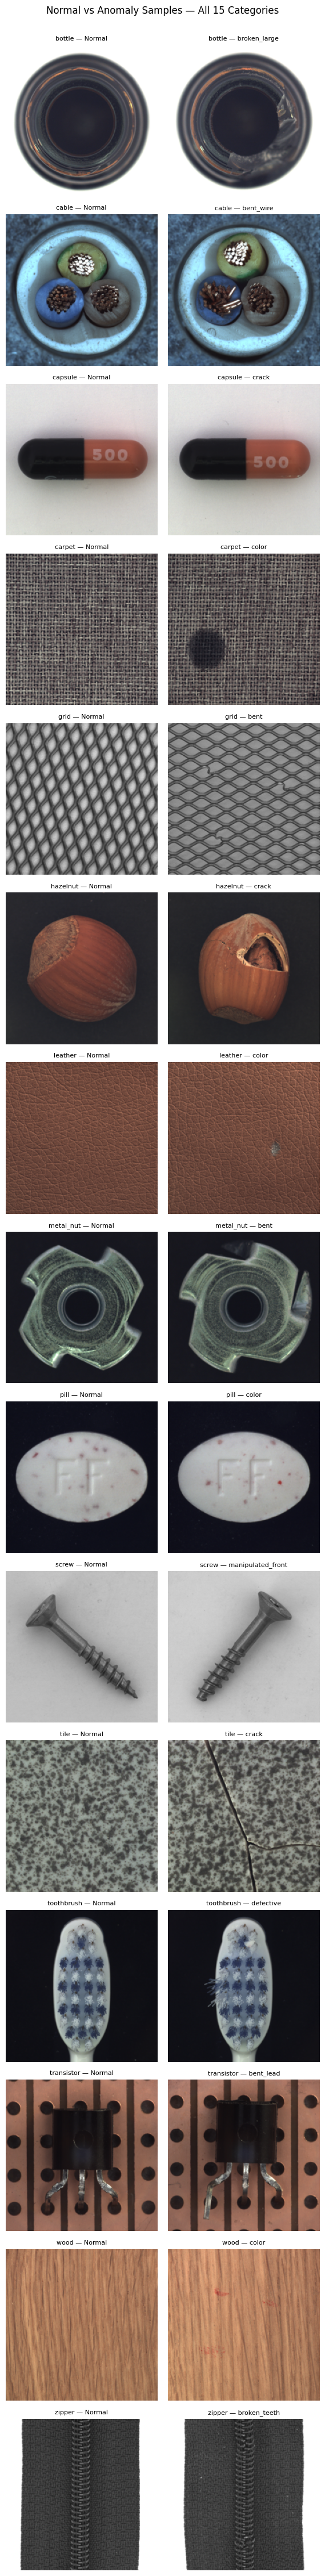

In [4]:
fig, axes = plt.subplots(15, 2, figsize=(6, 45))

for i, category in enumerate(CATEGORIES):
    test_dir = DATA_ROOT / category / 'test'

    normal_imgs = list((test_dir / 'good').glob('*.png'))
    if normal_imgs:
        img = Image.open(normal_imgs[0]).convert('RGB').resize((224, 224))
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'{category} — Normal', fontsize=8)
        axes[i, 0].axis('off')

    defect_dirs = [d for d in os.listdir(test_dir)
                   if d != 'good' and (test_dir / d).is_dir()]
    if defect_dirs:
        anomaly_imgs = list((test_dir / defect_dirs[0]).glob('*.png'))
        if anomaly_imgs:
            img = Image.open(anomaly_imgs[0]).convert('RGB').resize((224, 224))
            axes[i, 1].imshow(img)
            axes[i, 1].set_title(f'{category} — {defect_dirs[0]}', fontsize=8)
            axes[i, 1].axis('off')

plt.suptitle('Normal vs Anomaly Samples — All 15 Categories', fontsize=12, y=1.001)
plt.tight_layout()
plt.savefig('../experiments/results/normal_vs_anomaly_samples.png', dpi=100, bbox_inches='tight')
plt.show()


## Defect Type Breakdown

In [5]:
print("Defect types per category:\n")
for s in stats:
    print(f"{s['category']}: {', '.join(s['defect_names'])}")

Defect types per category:

bottle: broken_large, broken_small, contamination
cable: bent_wire, cable_swap, combined, cut_inner_insulation, cut_outer_insulation, missing_cable, missing_wire, poke_insulation
capsule: crack, faulty_imprint, poke, scratch, squeeze
carpet: color, cut, hole, metal_contamination, thread
grid: bent, broken, glue, metal_contamination, thread
hazelnut: crack, cut, hole, print
leather: color, cut, fold, glue, poke
metal_nut: bent, color, flip, scratch
pill: color, combined, contamination, crack, faulty_imprint, pill_type, scratch
screw: manipulated_front, scratch_head, scratch_neck, thread_side, thread_top
tile: crack, glue_strip, gray_stroke, oil, rough
toothbrush: defective
transistor: bent_lead, cut_lead, damaged_case, misplaced
wood: color, combined, hole, liquid, scratch
zipper: broken_teeth, combined, fabric_border, fabric_interior, rough, split_teeth, squeezed_teeth


## Key Observations

- The dataset is heavily imbalanced - anomalous images outnumber normal test images in most
  categories. For example screw has 41 normal vs 119 anomaly test images. Accuracy would be
  misleading here. AUROC is the correct metric.
- Texture categories (carpet, leather, tile) have visually distinct anomalies - color patches,
  cuts, cracks - that stand out clearly against consistent backgrounds.
- Structural categories (screw, transistor) appear at different orientations in normal images,
  making the normal feature distribution wider and harder to separate from anomalies.
- Screw has 5 fine-grained defect types including manipulated_front and scratch_neck which are
  nearly indistinguishable from normal even visually. This directly foreshadows its AUROC of 0.879.